# First Imports

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
import joblib

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

# Data

In [2]:
root_path = '/content/drive/MyDrive/Trellis/data/full_data'
data_contents = []

for root, dirs, files in os.walk(root_path):
    for file_name in files:
        file_path = os.path.join(root, file_name)
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                relative_path = os.path.relpath(file_path, root_path)
                # data_contents[relative_path] = f.read()
                data_contents.append(
                    [relative_path,
                     relative_path.split('/')[0],
                     relative_path.split('/')[1],
                     re.search(r'_(\d+)',relative_path.split('/')[1]).group(1),
                     f.read()]
                    )
        except Exception as e:
            print(f"Could not read file {file_path}: {e}")

print(f"Captured contents from {len(data_contents)} files.")

df_data = pd.DataFrame(data_contents, columns=['path_to_file','class','file_name','_file_num','file_content'])

Captured contents from 1006 files.


# Explore

In [3]:
display(df_data.sample(random_state=40))
print('\n\n--------\n\n')
print(df_data.sample(random_state=40).iloc[0].file_content)
print('\n\n--------\n\n')
print(df_data['class'].value_counts())
print('\n\n--------\n\n')
print(df_data.info())

,path_to_file,class,file_name,_file_num,file_content
744,space/space_83.txt,space,space_83.txt,83,In article <C4t3K3.498@cck.coventry.ac.uk> enf...




--------


In article <C4t3K3.498@cck.coventry.ac.uk> enf021@cck.coventry.ac.uk (Achurist) writes:
|I believe the reason is that the lung diaphram gets too tired to pump
|the liquid in and out and simply stops breathing after 2-3 minutes.
|So if your in the vehicle ready to go they better not put you on 
|hold, or else!! That's about it. Remember a liquid is several more times
|as dense as a gas by its very nature. ~10 I think, depending on the gas
|and liquid comparision of course!
Could you use some sort of mechanical chest compression as an aid.
Sorta like the portable Iron Lung?   Put some sort of flex tubing
around the 'aquanauts' chest.  Cyclically compress it  and it will
push enough on the chest wall to support breathing?????
You'd have to trust your breather,  but in space, you have to trust
your suit anyway.
pat



--------


class
business         100
politics         100
technologie      100
sport            100
entertainment    100
food             100
historical       1

# Train test split

In [4]:
from sklearn.model_selection import train_test_split

df_model = df_data[df_data["class"].str.lower() != "other"].copy()

X = df_model["file_content"]
y = df_model["class"].str.lower()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

df_full_test = pd.concat([X_test, y_test], axis=1)
df_full_test = pd.concat([df_full_test, df_data[df_data["class"].str.lower() == "other"][['file_content','class']]])

In [5]:
y

,class
0,business
1,business
2,business
3,business
4,business
...,...
1001,graphics
1002,graphics
1003,graphics
1004,graphics


In [6]:
# pd.concat([X_train, y_train], axis=1)['class'].value_counts()
# pd.concat([X_test, y_test], axis=1)['class'].value_counts()

In [7]:
df_data['class'].value_counts()

,count
class,
business,100
politics,100
technologie,100
sport,100
entertainment,100
food,100
historical,100
medical,100
space,100


# Models

### TF-IDF + SVM

##### V1

In [29]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", LinearSVC(
        C=1.0,
        # class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)

# Training accuracy
train_accuracy = svm_pipeline.score(X_train, y_train)

# Test accuracy
test_accuracy = svm_pipeline.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



Training Accuracy: 1.0000
Test Accuracy: 0.9750


Training versus test - check for overfitting

In [11]:
# Training accuracy
train_accuracy = svm_pipeline.score(X_train, y_train)

# Test accuracy
test_accuracy = svm_pipeline.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9750


In [44]:
y_pred = svm_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.97

Classification Report:

               precision    recall  f1-score   support

     business       1.00      0.90      0.95        20
entertainment       0.95      1.00      0.98        20
         food       1.00      1.00      1.00        20
     graphics       0.87      1.00      0.93        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
     politics       0.91      1.00      0.95        20
        space       1.00      0.80      0.89        20
        sport       1.00      1.00      1.00        20
  technologie       1.00      1.00      1.00        20

     accuracy                           0.97       200
    macro avg       0.97      0.97      0.97       200
 weighted avg       0.97      0.97      0.97       200



In [9]:
# Accuracy on training data
y_pred_train = svm_pipeline.predict(X_train)


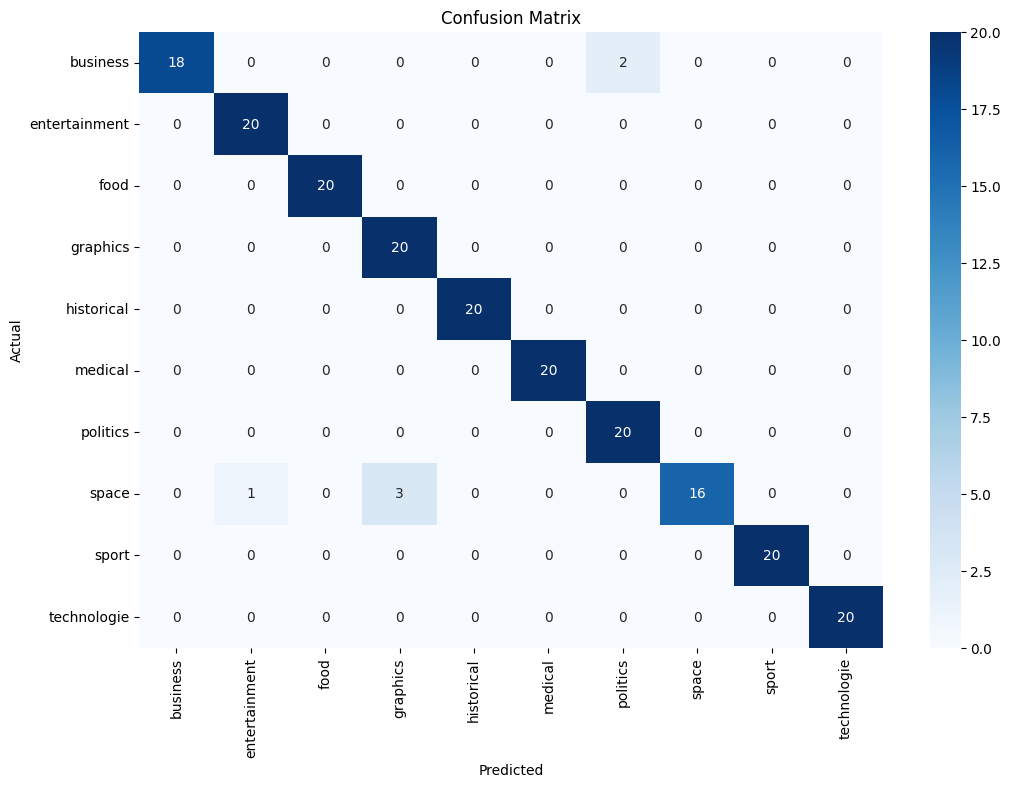

In [46]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Adapting for "OTHERS"

In [55]:
base_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("classifier", CalibratedClassifierCV(
        estimator=LinearSVC(
            C=1.0,
            # class_weight="balanced",
            random_state=42
        ),
        cv=3
    ))
])

base_svm.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=50000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('classifier',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(random_state=42)))])

Checking OTHERS results

In [63]:
probas = base_svm.predict_proba(X_test)
max_probas = np.max(probas, axis=1)
# print(max_probas)
raw_preds = base_svm.predict(X_test)

threshold = 0.55

threshold_preds = [
    pred if confidence >= threshold else "other"
    for pred, confidence in zip(raw_preds, max_probas)
]

print(classification_report(y_test, raw_preds))

df_other = df_data[df_data["class"].str.lower() == "other"].copy()

other_probas = base_svm.predict_proba(df_other["file_content"])
other_confidences = np.max(other_probas, axis=1)
other_raw_preds = base_svm.predict(df_other["file_content"])

other_final_preds = [
    pred if confidence >= threshold else "other"
    for pred, confidence in zip(other_raw_preds, other_confidences)
]

df_other_results = df_other[["path_to_file", "class", "file_name"]].copy()
df_other_results["raw_prediction"] = other_raw_preds
df_other_results["confidence"] = other_confidences
df_other_results["final_prediction"] = other_final_preds

display(df_other_results.head(20))

               precision    recall  f1-score   support

     business       1.00      0.90      0.95        20
entertainment       0.95      1.00      0.98        20
         food       1.00      1.00      1.00        20
     graphics       0.95      1.00      0.98        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
     politics       0.91      1.00      0.95        20
        space       1.00      0.90      0.95        20
        sport       1.00      1.00      1.00        20
  technologie       1.00      1.00      1.00        20

     accuracy                           0.98       200
    macro avg       0.98      0.98      0.98       200
 weighted avg       0.98      0.98      0.98       200



,path_to_file,class,file_name,raw_prediction,confidence,final_prediction
0,other/other_6.txt,other,other_6.txt,graphics,0.339757,other
1,other/other_1.txt,other,other_1.txt,entertainment,0.243872,other
2,other/other_4.txt,other,other_4.txt,technologie,0.334075,other
3,other/other_3.txt,other,other_3.txt,historical,0.133836,other
4,other/other_5.txt,other,other_5.txt,technologie,0.504168,other
5,other/other_2.txt,other,other_2.txt,sport,0.537921,other


Checking results with "OTHERS" in the test dataset

In [77]:
# With df_full_test
probas = base_svm.predict_proba(df_full_test['file_content'])
max_probas = np.max(probas, axis=1)
# print(max_probas)
raw_preds = base_svm.predict(df_full_test['file_content'])

threshold = 0.45

threshold_preds = [
    pred if confidence >= threshold else "other"
    for pred, confidence in zip(raw_preds, max_probas)
]

df_full_test['pred'] = threshold_preds

df_full_test['pred_confidence'] = max_probas

# print(classification_report(df_full_test['class'], raw_preds))
print(classification_report(df_full_test['class'], df_full_test['pred']))
display(df_full_test)
display(df_full_test[df_full_test['pred']=='other'])

               precision    recall  f1-score   support

     business       1.00      0.90      0.95        20
entertainment       0.95      1.00      0.98        20
         food       1.00      1.00      1.00        20
     graphics       1.00      1.00      1.00        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
        other       0.50      0.67      0.57         6
     politics       1.00      1.00      1.00        20
        space       1.00      0.85      0.92        20
        sport       0.95      1.00      0.98        20
  technologie       0.95      1.00      0.98        20

     accuracy                           0.97       206
    macro avg       0.94      0.95      0.94       206
 weighted avg       0.97      0.97      0.97       206



,file_content,class,pred,pred_confidence
577,Baghdad Blogger on big screen\n\nA film based ...,entertainment,entertainment,0.949038
298,Small firms 'hit by rising costs'\n\nRising fu...,business,business,0.937526
376,Blair blasts Tory spending plans\n\nTony Blair...,politics,politics,0.978444
841,In article <1rhfrkINN816@shelley.u.washington....,medical,medical,0.955018
227,Saab to build Cadillacs in Sweden\n\nGeneral M...,business,business,0.925905
...,...,...,...,...
1,\nOnce upon a late spring afternoon in the qui...,other,other,0.243872
2,This is a text with nothing to do with a commo...,other,other,0.334075
3,"In an inspiring display of community spirit, r...",other,other,0.133836
4,This is a text that have nothing to do with th...,other,technologie,0.504168


,file_content,class,pred,pred_confidence
292,Russia WTO talks 'make progress'\n\nTalks on R...,business,other,0.432222
243,Saudi ministry to employ women\n\nWomen will b...,business,other,0.417207
116,>If all the ecomomists in the world were laid ...,space,other,0.337489
132,"I read it refered to as the ""parabolic cross-s...",space,other,0.248772
0,The Elmwood District Library has introduced a ...,other,other,0.339757
1,\nOnce upon a late spring afternoon in the qui...,other,other,0.243872
2,This is a text with nothing to do with a commo...,other,other,0.334075
3,"In an inspiring display of community spirit, r...",other,other,0.133836


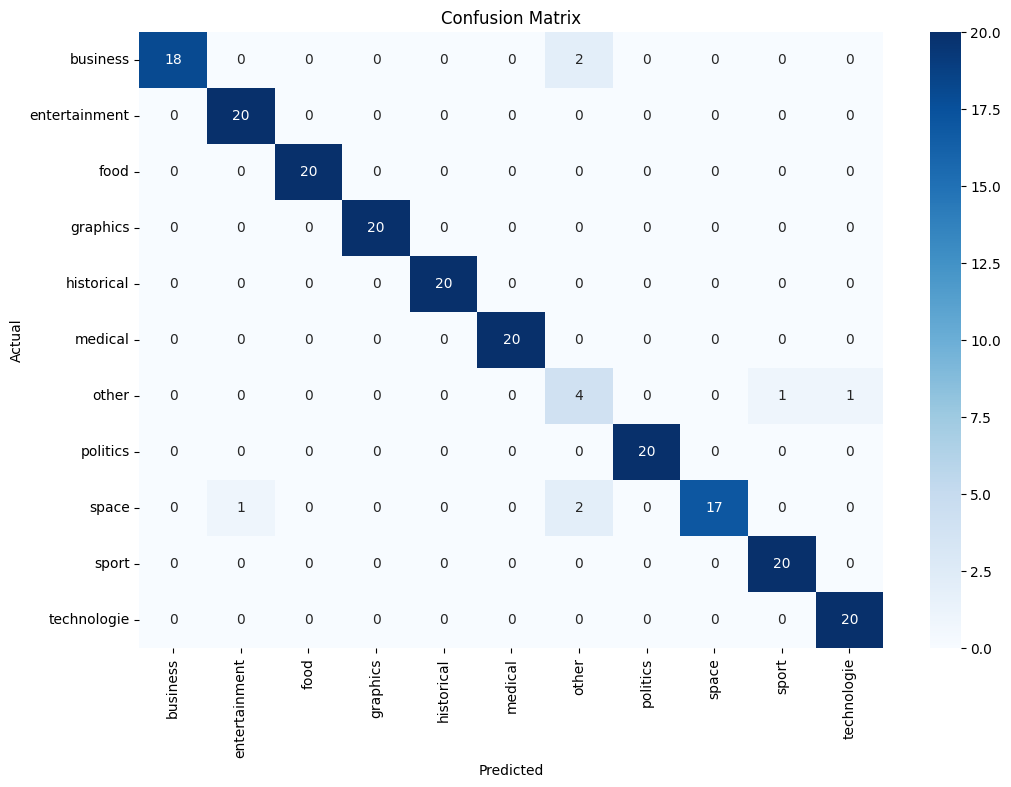

In [79]:
labels = sorted(df_full_test['pred'].unique())

cm = confusion_matrix(df_full_test['class'], df_full_test['pred'], labels=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Good performance but "others" with precision = 0.5**

##### V2

*Good results, so I'll search for better hyperparameters*

*I won't run GridSearchCV to save time, given that the study case mentions not to spend too much time tuning the model*

In [12]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=50000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9
    )),
    ("classifier", LinearSVC(
        C=1,
        class_weight="balanced",
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)

# Training accuracy
train_accuracy = svm_pipeline.score(X_train, y_train)

# Test accuracy
test_accuracy = svm_pipeline.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



Training Accuracy: 1.0000
Test Accuracy: 0.9800


**Small improvement here: max_df=0.9**

In [9]:
y_pred = svm_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.98

Classification Report:

               precision    recall  f1-score   support

     business       0.91      1.00      0.95        20
entertainment       1.00      1.00      1.00        20
         food       1.00      1.00      1.00        20
     graphics       0.95      0.95      0.95        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
     politics       1.00      0.95      0.97        20
        space       0.95      0.95      0.95        20
        sport       1.00      1.00      1.00        20
  technologie       1.00      0.95      0.97        20

     accuracy                           0.98       200
    macro avg       0.98      0.98      0.98       200
 weighted avg       0.98      0.98      0.98       200



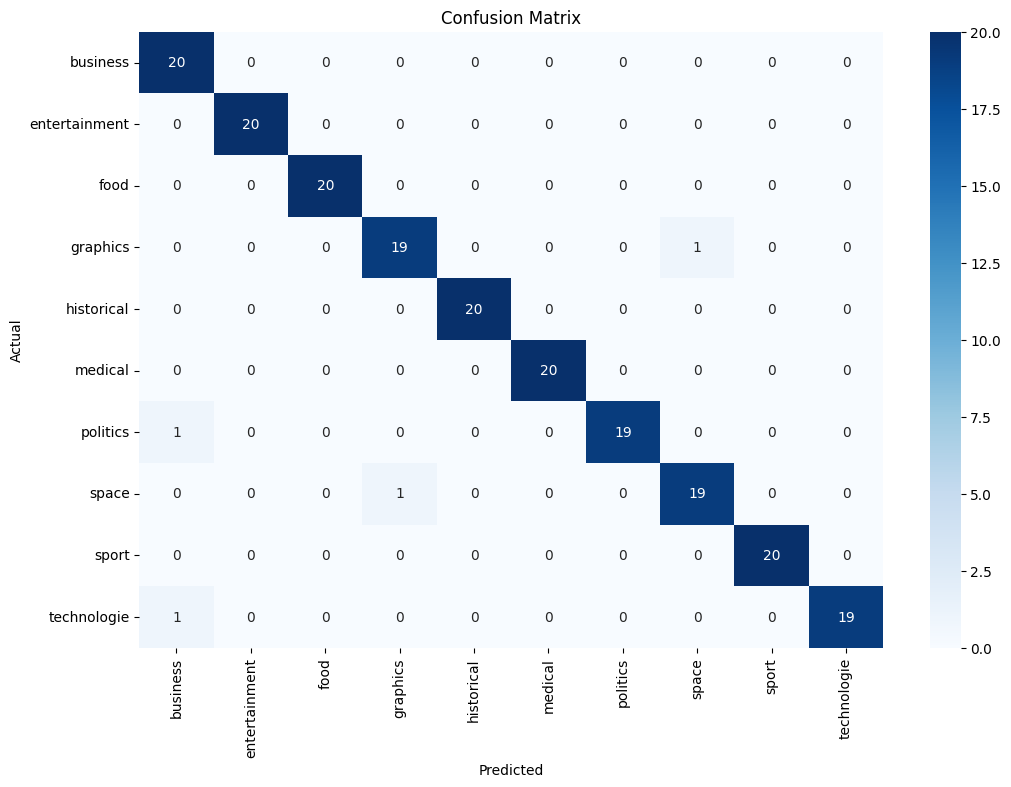

In [10]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Adapting for "OTHERS" -> fitting again using CalibratedClassifierCV to map probabilities and use predict_proba -> Traditional LinearSVC optimizes classification margins, not probability estimation.

In [19]:
base_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9
    )),
    ("classifier", CalibratedClassifierCV(
        estimator=LinearSVC(
            C=1.0,
            # class_weight="balanced",
            random_state=42
        ),
        cv=3
    ))
])

base_svm.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=50000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('classifier',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(random_state=42)))])

Checking OTHERS results

In [20]:
probas = base_svm.predict_proba(X_test)
max_probas = np.max(probas, axis=1)
# print(max_probas)
raw_preds = base_svm.predict(X_test)

threshold = 0.55

threshold_preds = [
    pred if confidence >= threshold else "other"
    for pred, confidence in zip(raw_preds, max_probas)
]

print(classification_report(y_test, raw_preds))

df_other = df_data[df_data["class"].str.lower() == "other"].copy()

other_probas = base_svm.predict_proba(df_other["file_content"])
other_confidences = np.max(other_probas, axis=1)
other_raw_preds = base_svm.predict(df_other["file_content"])

other_final_preds = [
    pred if confidence >= threshold else "other"
    for pred, confidence in zip(other_raw_preds, other_confidences)
]

df_other_results = df_other[["path_to_file", "class", "file_name"]].copy()
df_other_results["raw_prediction"] = other_raw_preds
df_other_results["confidence"] = other_confidences
df_other_results["final_prediction"] = other_final_preds

display(df_other_results.head(20))

               precision    recall  f1-score   support

     business       0.91      1.00      0.95        20
entertainment       1.00      1.00      1.00        20
         food       1.00      1.00      1.00        20
     graphics       1.00      0.95      0.97        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
     politics       1.00      0.95      0.97        20
        space       0.95      0.95      0.95        20
        sport       0.95      1.00      0.98        20
  technologie       1.00      0.95      0.97        20

     accuracy                           0.98       200
    macro avg       0.98      0.98      0.98       200
 weighted avg       0.98      0.98      0.98       200



,path_to_file,class,file_name,raw_prediction,confidence,final_prediction
400,other/other_2.txt,other,other_2.txt,sport,0.527431,other
401,other/other_1.txt,other,other_1.txt,entertainment,0.307678,other
402,other/other_3.txt,other,other_3.txt,historical,0.186502,other
403,other/other_4.txt,other,other_4.txt,technologie,0.345673,other
404,other/other_6.txt,other,other_6.txt,graphics,0.331670,other
405,other/other_5.txt,other,other_5.txt,technologie,0.495035,other


Checking results with "OTHERS" in the test dataset

In [26]:
# With df_full_test
probas = base_svm.predict_proba(df_full_test['file_content'])
max_probas = np.max(probas, axis=1)
# print(max_probas)
raw_preds = base_svm.predict(df_full_test['file_content'])

threshold = 0.45

threshold_preds = [
    pred if confidence >= threshold else "other"
    for pred, confidence in zip(raw_preds, max_probas)
]

df_full_test['pred'] = threshold_preds

df_full_test['pred_confidence'] = max_probas

# print(classification_report(df_full_test['class'], raw_preds))
print(classification_report(df_full_test['class'], df_full_test['pred']))
display(df_full_test)
display(df_full_test[df_full_test['pred']=='other'])

               precision    recall  f1-score   support

     business       0.95      1.00      0.98        20
entertainment       1.00      1.00      1.00        20
         food       1.00      1.00      1.00        20
     graphics       1.00      0.90      0.95        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
        other       0.50      0.67      0.57         6
     politics       1.00      0.95      0.97        20
        space       0.95      0.95      0.95        20
        sport       0.95      1.00      0.98        20
  technologie       0.95      0.90      0.92        20

     accuracy                           0.96       206
    macro avg       0.94      0.94      0.94       206
 weighted avg       0.97      0.96      0.96       206



,file_content,class,pred,pred_confidence
477,UK Directors Guild nominees named\n\nMartin Sc...,entertainment,entertainment,0.951320
92,Oil rebounds from weather effect\n\nOil prices...,business,business,0.933062
170,Cabinet anger at Brown cash raid\n\nMinisters ...,politics,politics,0.956783
841,In article <1993Apr14.184444.24065@galileo.cc....,medical,medical,0.796254
21,Asian quake hits European shares\n\nShares in ...,business,business,0.944267
...,...,...,...,...
401,\nOnce upon a late spring afternoon in the qui...,other,other,0.307678
402,"In an inspiring display of community spirit, r...",other,other,0.186502
403,This is a text with nothing to do with a commo...,other,other,0.345673
404,The Elmwood District Library has introduced a ...,other,other,0.331670


,file_content,class,pred,pred_confidence
943,In article <7155@pdxgate.UUCP> idr@rigel.cs.pd...,graphics,other,0.405954
263,Startup Deploying AI Chatbots With “Conversati...,technologie,other,0.339772
754,Sterrenkundig symposium 'Compacte Objecten'\n ...,space,other,0.256484
287,US woman sues over cartridges\n\nA US woman is...,technologie,other,0.325506
401,\nOnce upon a late spring afternoon in the qui...,other,other,0.307678
402,"In an inspiring display of community spirit, r...",other,other,0.186502
403,This is a text with nothing to do with a commo...,other,other,0.345673
404,The Elmwood District Library has introduced a ...,other,other,0.331670


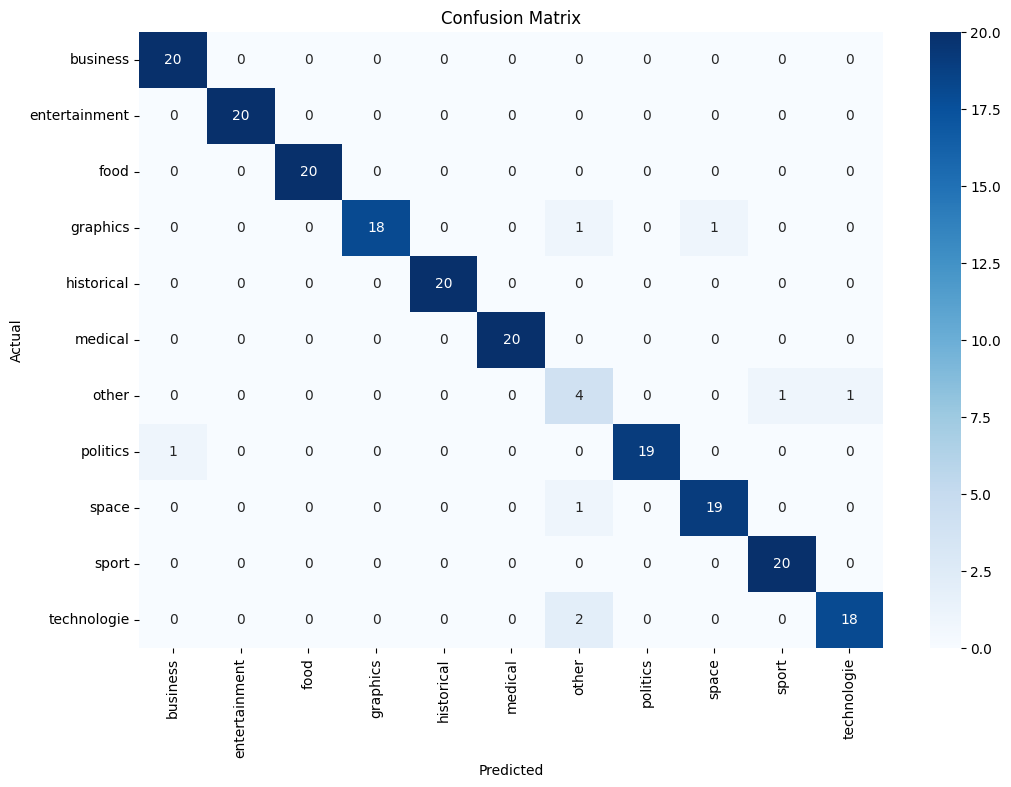

In [27]:
labels = sorted(df_full_test['pred'].unique())

cm = confusion_matrix(df_full_test['class'], df_full_test['pred'], labels=labels)

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
# from sklearn.metrics import precision_recall_curve, average_precision_score

# y_true_other = (df_full_test["class"].str.lower() == "other").astype(int)

# probas = base_svm.predict_proba(df_full_test["file_content"])

# classes = base_svm.named_steps["classifier"].classes_

# if "other" in classes:
#     other_index = list(classes).index("other")
#     other_scores = probas[:, other_index]

# # If "other" is NOT a trained class, use uncertainty score
# else:
#     other_scores = 1 - np.max(probas, axis=1)

# precision, recall, thresholds = precision_recall_curve(
#     y_true_other,
#     other_scores
# )

# avg_precision = average_precision_score(
#     y_true_other,
#     other_scores
# )

# plt.figure(figsize=(8, 6))
# plt.plot(recall, precision, label=f"AP = {avg_precision:.4f}")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title('Precision-Recall Curve for "other" Class')
# plt.legend()
# plt.grid(True)
# plt.show()

### ModerBERT | Using T4 GPU in google colab

I'm adding a layer with 10 classes and I'll classify as "others" when the confidence is low for the other classes

Phase 1 - Freeze backbone and train ONLY the classification head to avoid GRADIENT SHOCKWAVE

Phase 2 - Unfreeze the full model

In [5]:
!pip install -q transformers accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


In [7]:
import torch

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm.auto import tqdm

In [8]:
MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 1024
BATCH_SIZE = 8
HEAD_EPOCHS = 3
FULL_EPOCHS = 2
HEAD_LR = 1e-3
FULL_LR = 1e-5
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(DEVICE)

cuda


##### Small data treatment for ModernBERT - *duplicated considering the treatment above, I'm just keeping it duplicated to save time* :D

In [9]:
df_model = df_data[df_data["class"].str.lower() != "other"].copy()
df_model["class"] = df_model["class"].str.lower()

labels = sorted(df_model["class"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

df_model["label_id"] = df_model["class"].map(label2id)

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_model["class"]
)

other_df = df_data[df_data["class"].str.lower() == "other"].copy()
other_df["class"] = "other"

df_full_test = pd.concat(
    [
        test_df[["file_content", "class"]],
        other_df[["file_content", "class"]]
    ],
    ignore_index=True
)

print(labels)
print(train_df.shape, test_df.shape, other_df.shape)

['business', 'entertainment', 'food', 'graphics', 'historical', 'medical', 'politics', 'space', 'sport', 'technologie']
(800, 6) (200, 6) (6, 5)


##### Tokenizer

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

##### torch - dataset

In [13]:
class DocumentDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=1024):
        self.texts = list(texts)
        self.labels = None if labels is None else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
        }

        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

In [14]:
train_dataset = DocumentDataset(
    train_df["file_content"],
    train_df["label_id"],
    tokenizer,
    MAX_LENGTH
)

test_dataset = DocumentDataset(
    test_df["file_content"],
    test_df["label_id"],
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

##### Model

*I'm adding a layer with 10 classes and I'll classify as "others" when the confidence is low for the other classes*

In [15]:
import torch.nn as nn
from transformers import AutoModel

NUM_LABELS = len(labels)

class ModernBERTClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels,
        dropout=0.2
    ):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(model_name)

        hidden_size = self.backbone.config.hidden_size

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(
        self,
        input_ids,
        attention_mask,
        labels=None
    ):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = outputs.last_hidden_state[:, 0]

        x = self.dropout(cls_embedding)

        logits = self.classifier(x)

        loss = None

        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }

model = ModernBERTClassifier(
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=0.2
)

model.to(DEVICE)

print(model)

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ModernBERTClassifier(
  (backbone): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      )
      (1-21): 21 x ModernBertEncoderLayer(
        (attn_norm)

In [16]:
from sklearn.metrics import precision_recall_fscore_support

In [17]:
def evaluate_model(model, data_loader, device, description="Evaluation"):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=description):

            batch = {
                k: v.to(device)
                for k, v in batch.items()
            }

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )

            loss = outputs["loss"]
            logits = outputs["logits"]

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }


def print_metrics(metrics, prefix=""):
    print(
        f"{prefix} "
        f"loss: {metrics['loss']:.4f} | "
        f"accuracy: {metrics['accuracy']:.4f} | "
        f"precision_macro: {metrics['precision_macro']:.4f} | "
        f"recall_macro: {metrics['recall_macro']:.4f} | "
        f"f1_macro: {metrics['f1_macro']:.4f}"
    )

In [18]:
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    scheduler,
    device,
    description="Training"
):
    model.train()

    total_loss = 0

    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc=description):

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        loss = outputs["loss"]
        logits = outputs["logits"]

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item()

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            batch["labels"].detach().cpu().numpy()
        )

    avg_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

##### Phase 1 - Freeze backbone and train ONLY the classification head to avoid GRADIENT SHOCKWAVE

In [19]:
for param in model.backbone.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable params: {trainable_params:,}")
print(f"Total params: {total_params:,}")

Trainable params: 7,690
Total params: 149,021,962


In [20]:
##### Optimizer and scheduler for head-only training

head_optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LR,
    weight_decay=0.01
)

num_training_steps = HEAD_EPOCHS * len(train_loader)

num_warmup_steps = int(
    0.1 * num_training_steps
)

head_scheduler = get_linear_schedule_with_warmup(
    head_optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

history = []

In [21]:
##### Train head only

for epoch in range(HEAD_EPOCHS):

    print(
        f"\nHEAD TRAINING EPOCH "
        f"{epoch + 1}/{HEAD_EPOCHS}"
    )

    train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=head_optimizer,
        scheduler=head_scheduler,
        device=DEVICE,
        description="Training head"
    )

    test_metrics = evaluate_model(
        model=model,
        data_loader=test_loader,
        device=DEVICE,
        description="Validation"
    )

    print_metrics(
        train_metrics,
        prefix="Train"
    )

    print_metrics(
        test_metrics,
        prefix="Valid"
    )

    history.append({
        "phase": "head_only",
        "epoch": epoch + 1,

        **{
            f"train_{k}": v
            for k, v in train_metrics.items()
        },

        **{
            f"valid_{k}": v
            for k, v in test_metrics.items()
        },
    })


HEAD TRAINING EPOCH 1/3


Training head:   0%|          | 0/100 [00:00<?, ?it/s]

W0512 22:17:57.811000 8079 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train loss: 1.8190 | accuracy: 0.3837 | precision_macro: 0.3938 | recall_macro: 0.3837 | f1_macro: 0.3844
Valid loss: 1.1536 | accuracy: 0.6900 | precision_macro: 0.7796 | recall_macro: 0.6900 | f1_macro: 0.6694

HEAD TRAINING EPOCH 2/3


...

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train loss: 0.9754 | accuracy: 0.7500 | precision_macro: 0.7543 | recall_macro: 0.7500 | f1_macro: 0.7481
Valid loss: 0.7896 | accuracy: 0.8300 | precision_macro: 0.8449 | recall_macro: 0.8300 | f1_macro: 0.8251

HEAD TRAINING EPOCH 3/3


Training head:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train loss: 0.7644 | accuracy: 0.8325 | precision_macro: 0.8321 | recall_macro: 0.8325 | f1_macro: 0.8313
Valid loss: 0.7181 | accuracy: 0.8650 | precision_macro: 0.8712 | recall_macro: 0.8650 | f1_macro: 0.8632


##### Phase 2 - Unfreeze the full model

In [22]:
for param in model.backbone.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable params: {trainable_params:,}")

Trainable params: 149,021,962


In [23]:
##### Differential learning rates
##### Lower LR for backbone, higher LR for classifier

backbone_params = []
classifier_params = []

for name, param in model.named_parameters():

    if "classifier" in name:
        classifier_params.append(param)
    else:
        backbone_params.append(param)

full_optimizer = AdamW(
    [
        {
            "params": backbone_params,
            "lr": FULL_LR,
            "weight_decay": 0.01
        },

        {
            "params": classifier_params,
            "lr": FULL_LR * 5,
            "weight_decay": 0.01
        },
    ]
)

num_training_steps = FULL_EPOCHS * len(train_loader)

num_warmup_steps = int(
    0.1 * num_training_steps
)

full_scheduler = get_linear_schedule_with_warmup(
    full_optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [24]:
##### Full fine-tuning

for epoch in range(FULL_EPOCHS):

    print(
        f"\nFULL FINE-TUNING EPOCH "
        f"{epoch + 1}/{FULL_EPOCHS}"
    )

    train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=full_optimizer,
        scheduler=full_scheduler,
        device=DEVICE,
        description="Fine-tuning full model"
    )

    test_metrics = evaluate_model(
        model=model,
        data_loader=test_loader,
        device=DEVICE,
        description="Validation"
    )

    print_metrics(
        train_metrics,
        prefix="Train"
    )

    print_metrics(
        test_metrics,
        prefix="Valid"
    )

    history.append({
        "phase": "full_finetuning",
        "epoch": epoch + 1,

        **{
            f"train_{k}": v
            for k, v in train_metrics.items()
        },

        **{
            f"valid_{k}": v
            for k, v in test_metrics.items()
        },
    })


FULL FINE-TUNING EPOCH 1/2


Fine-tuning full model:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train loss: 0.2511 | accuracy: 0.9287 | precision_macro: 0.9295 | recall_macro: 0.9287 | f1_macro: 0.9286
Valid loss: 0.0692 | accuracy: 0.9750 | precision_macro: 0.9768 | recall_macro: 0.9750 | f1_macro: 0.9751

FULL FINE-TUNING EPOCH 2/2


Fine-tuning full model:   0%|          | 0/100 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train loss: 0.0308 | accuracy: 0.9925 | precision_macro: 0.9925 | recall_macro: 0.9925 | f1_macro: 0.9925
Valid loss: 0.0401 | accuracy: 0.9900 | precision_macro: 0.9905 | recall_macro: 0.9900 | f1_macro: 0.9900


In [27]:
##### Training history

history_df = pd.DataFrame(history)

history_df

,phase,epoch,train_loss,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,valid_loss,valid_accuracy,valid_precision_macro,valid_recall_macro,valid_f1_macro
0,head_only,1,1.818966,0.38375,0.393760,0.38375,0.384398,1.153579,0.690,0.779639,0.690,0.669443
1,head_only,2,0.975397,0.75000,0.754253,0.75000,0.748098,0.789600,0.830,0.844859,0.830,0.825142
2,head_only,3,0.764411,0.83250,0.832066,0.83250,0.831278,0.718072,0.865,0.871234,0.865,0.863208
3,full_finetuning,1,0.251086,0.92875,0.929538,0.92875,0.928647,0.069249,0.975,0.976818,0.975,0.975085
4,full_finetuning,2,0.030762,0.99250,0.992500,0.99250,0.992492,0.040080,0.990,0.990476,0.990,0.989994


##### Final classification report

In [28]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in tqdm(
        test_loader,
        desc="Final validation predictions"
    ):

        batch = {
            k: v.to(DEVICE)
            for k, v in batch.items()
        }

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        logits = outputs["logits"]

        preds = torch.argmax(
            logits,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            batch["labels"].cpu().numpy()
        )

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=labels,
        zero_division=0
    )
)

Final validation predictions:   0%|          | 0/25 [00:00<?, ?it/s]

               precision    recall  f1-score   support

     business       1.00      0.95      0.97        20
entertainment       1.00      1.00      1.00        20
         food       1.00      1.00      1.00        20
     graphics       1.00      0.95      0.97        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
     politics       0.95      1.00      0.98        20
        space       0.95      1.00      0.98        20
        sport       1.00      1.00      1.00        20
  technologie       1.00      1.00      1.00        20

     accuracy                           0.99       200
    macro avg       0.99      0.99      0.99       200
 weighted avg       0.99      0.99      0.99       200



##### Softmax confidence threshold for "other"

In [29]:
import torch.nn.functional as F

CONFIDENCE_THRESHOLD = 0.50

def predict_document(
    text,
    model,
    tokenizer,
    max_length=1024,
    threshold=0.60
):
    model.eval()

    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    encoded = {
        k: v.to(DEVICE)
        for k, v in encoded.items()
    }

    with torch.no_grad():

        outputs = model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"]
        )

        logits = outputs["logits"]

        probs = F.softmax(
            logits,
            dim=1
        )

        confidence, pred_idx = torch.max(
            probs,
            dim=1
        )

    confidence = confidence.item()

    pred_idx = pred_idx.item()

    if confidence < threshold:
        predicted_label = "other"
    else:
        predicted_label = id2label[pred_idx]

    return {
        "predicted_label": predicted_label,
        "confidence": confidence
    }

In [30]:
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import classification_report

threshold = 0.4

full_test_dataset = DocumentDataset(
    df_full_test["file_content"],
    labels=None,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

full_test_loader = DataLoader(
    full_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

model.eval()

all_raw_preds = []
all_threshold_preds = []
all_confidences = []

with torch.no_grad():

    for batch in tqdm(full_test_loader, desc="Predicting full test set"):

        batch = {
            k: v.to(DEVICE)
            for k, v in batch.items()
        }

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        logits = outputs["logits"]

        probas = F.softmax(logits, dim=1)

        max_probas, pred_ids = torch.max(probas, dim=1)

        raw_preds = [
            id2label[pred_id.item()]
            for pred_id in pred_ids
        ]

        confidences = max_probas.cpu().numpy()

        threshold_preds = [
            pred if confidence >= threshold else "other"
            for pred, confidence in zip(raw_preds, confidences)
        ]

        all_raw_preds.extend(raw_preds)
        all_threshold_preds.extend(threshold_preds)
        all_confidences.extend(confidences)


df_full_test_ModernBERT = df_full_test.copy()

df_full_test_ModernBERT["raw_pred"] = all_raw_preds
df_full_test_ModernBERT["pred"] = all_threshold_preds
df_full_test_ModernBERT["pred_confidence"] = all_confidences

print(
    classification_report(
        df_full_test_ModernBERT["class"],
        df_full_test_ModernBERT["pred"],
        zero_division=0
    )
)

display(df_full_test_ModernBERT)

display(
    df_full_test_ModernBERT[df_full_test_ModernBERT["pred"] == "other"]
)

Predicting full test set:   0%|          | 0/26 [00:00<?, ?it/s]

               precision    recall  f1-score   support

     business       1.00      0.95      0.97        20
entertainment       1.00      1.00      1.00        20
         food       0.95      1.00      0.98        20
     graphics       0.95      0.95      0.95        20
   historical       0.95      1.00      0.98        20
      medical       0.95      1.00      0.98        20
        other       1.00      0.33      0.50         6
     politics       0.95      1.00      0.98        20
        space       0.95      1.00      0.98        20
        sport       1.00      1.00      1.00        20
  technologie       1.00      1.00      1.00        20

     accuracy                           0.97       206
    macro avg       0.97      0.93      0.94       206
 weighted avg       0.97      0.97      0.97       206



,file_content,class,raw_pred,pred,pred_confidence
0,UK Directors Guild nominees named\n\nMartin Sc...,entertainment,entertainment,entertainment,0.999828
1,Oil rebounds from weather effect\n\nOil prices...,business,business,business,0.999942
2,Cabinet anger at Brown cash raid\n\nMinisters ...,politics,politics,politics,0.996863
3,In article <1993Apr14.184444.24065@galileo.cc....,medical,medical,medical,0.997437
4,Asian quake hits European shares\n\nShares in ...,business,business,business,0.999674
...,...,...,...,...,...
201,\nOnce upon a late spring afternoon in the qui...,other,food,food,0.732042
202,"In an inspiring display of community spirit, r...",other,graphics,other,0.346513
203,This is a text with nothing to do with a commo...,other,medical,medical,0.705297
204,The Elmwood District Library has introduced a ...,other,technologie,other,0.361943


,file_content,class,raw_pred,pred,pred_confidence
202,"In an inspiring display of community spirit, r...",other,graphics,other,0.346513
204,The Elmwood District Library has introduced a ...,other,technologie,other,0.361943


##### Inferencw

In [24]:
sample_text = test_df.iloc[0]["file_content"]

prediction = predict_document(
    sample_text,
    model,
    tokenizer,
    threshold=CONFIDENCE_THRESHOLD
)

prediction

{'predicted_label': 'entertainment', 'confidence': 0.999509334564209}

##### Save model

In [25]:
SAVE_DIR = "./modernbert_document_classifier"

torch.save(
    model.state_dict(),
    f"{SAVE_DIR}_weights.pth"
)

tokenizer.save_pretrained(SAVE_DIR)

print("Model and tokenizer saved.")

Model and tokenizer saved.


### ...

### Final Classification Report (TF-IDF + Linear SVM with Threshold = 0.45)

```text
               precision    recall  f1-score   support

     business       0.95      1.00      0.98        20
entertainment       1.00      1.00      1.00        20
         food       1.00      1.00      1.00        20
     graphics       1.00      0.90      0.95        20
   historical       1.00      1.00      1.00        20
      medical       1.00      1.00      1.00        20
        other       0.50      0.67      0.57         6
     politics       1.00      0.95      0.97        20
        space       0.95      0.95      0.95        20
        sport       0.95      1.00      0.98        20
  technologie       0.95      0.90      0.92        20

     accuracy                           0.96       206
    macro avg       0.94      0.94      0.94       206
 weighted avg       0.97      0.96      0.96       206
```


The TF-IDF + LinearSVC pipeline achieved strong performance across the known categories, reaching high accuracy and macro F1-score while maintaining low computational cost and fast inference times. These characteristics make the solution suitable for scalable production environments where millions of documents may need to be classified efficiently.

The ModernBERT arquitecture reaches even better performance, but the computational cost is high, so

One of the primary challenges identified was the detection of documents belonging to the other category, since these samples represent unseen or out-of-distribution data rather than a supervised class. To address this, a confidence-threshold strategy was adopted to improve rejection of low-confidence predictions